# New Levene test - 260527

In [16]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [17]:
final_df=pd.read_csv('/Users/gracieshao/Desktop/ALS T1s/data/preprocessed/final_cleaned_zscored_features_COMBINED.csv')

# Levene test - one sided, patients more variant than controls

In [18]:
from scipy.stats import levene
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

final_df = pd.read_csv('/Users/gracieshao/Desktop/ALS T1s/data/preprocessed/final_cleaned_zscored_features_COMBINED.csv')

META_COLS = ['INFO_PatientName', 'INFO_NameOfRoi']
FEAT_COLS = [c for c in final_df.columns if c not in META_COLS]

# ── Parse metadata from INFO_PatientName ──────────────────────────────────────
parts = final_df['INFO_PatientName'].str.split('_')
final_df['Study']     = parts.str[0]
final_df['SiteCode']  = parts.str[1]
final_df['SubjectID'] = parts.str[2]
final_df['Visit']     = parts.str.get(4)
final_df['Group']     = final_df['SubjectID'].str[0].map(
                            {'P': 'Patient', 'C': 'Control'})

# ── Visit 1 only ──────────────────────────────────────────────────────────────
v1_df        = final_df[final_df['Visit'] == 'V1'].copy()
patient_mask = v1_df['Group'] == 'Patient'
control_mask = v1_df['Group'] == 'Control'

unique_subj = v1_df.drop_duplicates(subset=['Study', 'SiteCode', 'SubjectID'])
summary = (unique_subj.groupby(['Study', 'Group']).size()
           .unstack(fill_value=0).assign(Total=lambda df: df.sum(axis=1)))
summary.loc['ALL'] = summary.sum()
print("=== V1 unique subjects ===")
print(summary.to_string())

# ── Levene per ROI × feature (one-sided p-value) ──────────────────────────────
# H0: var_pat = var_ctrl
# H1: var_pat > var_ctrl  (directional — patients more heterogeneous)
# One-sided p = two-sided p / 2  (valid only when var_ratio > 1, i.e. correct direction)

results = []
rois = v1_df['INFO_NameOfRoi'].unique()
print(f'\nRunning Levene across {len(rois)} ROIs × {len(FEAT_COLS)} features...')

for roi in rois:
    roi_mask  = v1_df['INFO_NameOfRoi'] == roi
    for feat in FEAT_COLS:
        pat_vals  = v1_df[roi_mask & patient_mask][feat].dropna()
        ctrl_vals = v1_df[roi_mask & control_mask][feat].dropna()
        if len(pat_vals) < 5 or len(ctrl_vals) < 5:
            continue
        stat, p_two = levene(pat_vals, ctrl_vals)
        var_ratio   = pat_vals.var() / (ctrl_vals.var() + 1e-8)

        # One-sided: only meaningful when var_ratio > 1 (correct direction)
        p_one = p_two / 2 if var_ratio > 1 else 1.0

        results.append({
            'roi':          roi,
            'feature':      feat,
            'levene_stat':  stat,
            'p_levene_two': p_two,
            'p_levene_one': p_one,     # ← one-sided p
            'var_ratio':    var_ratio,
            'pat_std':      pat_vals.std(),
            'ctrl_std':     ctrl_vals.std(),
            'pat_mean':     pat_vals.mean(),
            'ctrl_mean':    ctrl_vals.mean(),
            'n_pat':        len(pat_vals),
            'n_ctrl':       len(ctrl_vals),
        })

results_df = pd.DataFrame(results)
print(f'Total combinations tested: {len(results_df)}')

# ── FDR on one-sided p-values ─────────────────────────────────────────────────
valid = results_df['p_levene_one'].notna()
results_df['p_fdr'] = np.nan
results_df.loc[valid, 'p_fdr'] = multipletests(
    results_df.loc[valid, 'p_levene_one'], method='fdr_bh')[1]
results_df['fdr_reject'] = results_df['p_fdr'] < 0.05

# ── Significant: var_ratio > 1 + FDR < 0.05 ──────────────────────────────────
sig_df = results_df[
    (results_df['var_ratio'] > 1) &
    (results_df['fdr_reject'] == True)
].sort_values('var_ratio', ascending=False).reset_index(drop=True)

print(f'Significant (var_ratio>1, one-sided FDR<0.05): {len(sig_df)}')

if len(sig_df) < 10:
    print('FDR too strict — falling back to one-sided raw p<0.05')
    sig_df = results_df[
        (results_df['var_ratio'] > 1) &
        (results_df['p_levene_one'] < 0.05)
    ].sort_values('var_ratio', ascending=False).reset_index(drop=True)
    print(f'Significant (var_ratio>1, one-sided raw p<0.05): {len(sig_df)}')

print(f'\nTop 20 significant ROI × features:')
print(sig_df[['roi','feature','var_ratio','p_levene_one',
              'p_fdr','n_pat','n_ctrl']].head(20).to_string(index=False))

sig_df.to_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/levene_sig_roi_features_combined.csv',
    index=False)
print(f'\nSaved: levene_sig_roi_features_combined.csv  ({len(sig_df)} features)')

=== V1 unique subjects ===
Group     Control  Patient  Total
Study                            
CALSNIC1       63       82    145
CALSNIC2      141      169    310
ALL           204      251    455

Running Levene across 117 ROIs × 100 features...
Total combinations tested: 11700
Significant (var_ratio>1, one-sided FDR<0.05): 90

Top 20 significant ROI × features:
                                    roi                                                                feature  var_ratio  p_levene_one    p_fdr  n_pat  n_ctrl
          JHU-WhiteMatter-labels-1mm_#4          INTENSITY-BASED-RIM_RIM-IntensityMean_Std(IBSI:No)[Intensity]  13.061715      0.000075 0.016508    251     204
          JHU-WhiteMatter-labels-1mm_#4 INTENSITY-BASED-RIM_RIM-IntensityMean-GradientMean(IBSI:No)[Intensity]   9.969573      0.000036 0.010374    251     204
          JHU-WhiteMatter-labels-1mm_#4  INTENSITY-BASED-RIM_RIM-IntensityMean-GradientMin(IBSI:No)[Intensity]   9.173963      0.000079 0.017037    251   

# Welch's T-test - does not assume equal variance

In [19]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# ── Load Levene-significant features ─────────────────────────────────────────
sig_df = pd.read_csv('/Users/gracieshao/Desktop/ALS T1s/Scripts/levene_sig_roi_features_combined.csv')
print(f'Levene-significant ROI × features to test: {len(sig_df)}')

# ── v1_df, patient_mask, control_mask should be in memory from Levene cell ───
# If not, re-run the parsing block:
# final_df = pd.read_csv('...COMBINED.csv')
# parts = final_df['INFO_PatientName'].str.split('_')
# final_df['Study'] = parts.str[0]; final_df['SubjectID'] = parts.str[2]
# final_df['Visit'] = parts.str.get(4)
# final_df['Group'] = final_df['SubjectID'].str[0].map({'P':'Patient','C':'Control'})
# v1_df = final_df[final_df['Visit'] == 'V1'].copy()
# patient_mask = v1_df['Group'] == 'Patient'
# control_mask = v1_df['Group'] == 'Control'

# ── Welch's t-test per ROI × feature ─────────────────────────────────────────
# Welch's (equal_var=False) because Levene already showed unequal variances
ttest_results = []

for _, row in sig_df.iterrows():
    roi  = row['roi']
    feat = row['feature']

    roi_mask  = v1_df['INFO_NameOfRoi'] == roi
    pat_vals  = v1_df[roi_mask & patient_mask][feat].dropna()
    ctrl_vals = v1_df[roi_mask & control_mask][feat].dropna()

    if len(pat_vals) < 5 or len(ctrl_vals) < 5:
        continue

    t_stat, p_val = ttest_ind(pat_vals, ctrl_vals, equal_var=False)

    # Cohen's d (effect size) — pooled std
    pooled_std = np.sqrt((pat_vals.std()**2 + ctrl_vals.std()**2) / 2)
    cohens_d   = (pat_vals.mean() - ctrl_vals.mean()) / (pooled_std + 1e-8)

    ttest_results.append({
        'roi':        roi,
        'feature':    feat,
        'var_ratio':  row['var_ratio'],
        't_stat':     t_stat,
        'p_ttest':    p_val,
        'cohens_d':   cohens_d,
        'abs_d':      abs(cohens_d),
        'pat_mean':   pat_vals.mean(),
        'ctrl_mean':  ctrl_vals.mean(),
        'pat_std':    pat_vals.std(),
        'ctrl_std':   ctrl_vals.std(),
        'n_pat':      len(pat_vals),
        'n_ctrl':     len(ctrl_vals),
    })

ttest_df = pd.DataFrame(ttest_results)
print(f'Tests run: {len(ttest_df)}')

# ── FDR correction ────────────────────────────────────────────────────────────
valid = ttest_df['p_ttest'].notna()
ttest_df['p_fdr'] = np.nan
ttest_df.loc[valid, 'p_fdr'] = multipletests(
    ttest_df.loc[valid, 'p_ttest'], method='fdr_bh')[1]

# ── Filter significant + rank by |Cohen's d| ─────────────────────────────────
sig_ttest_df = (
    ttest_df[ttest_df['p_fdr'] < 0.05]
    .sort_values('abs_d', ascending=False)
    .reset_index(drop=True)
)

print(f'Significant after t-test FDR<0.05: {len(sig_ttest_df)}')

if len(sig_ttest_df) < 10:
    print('FDR too strict — falling back to raw p<0.05')
    sig_ttest_df = (
        ttest_df[ttest_df['p_ttest'] < 0.05]
        .sort_values('abs_d', ascending=False)
        .reset_index(drop=True)
    )
    print(f'Significant (raw p<0.05): {len(sig_ttest_df)}')

# ── Top 10 ────────────────────────────────────────────────────────────────────
top10 = sig_ttest_df.head(10).copy()

print('\nTop 10 ROI × features (ranked by |Cohen\'s d|):')
print(top10[['roi', 'feature', 'cohens_d', 'p_ttest', 'p_fdr',
             'pat_mean', 'ctrl_mean', 'n_pat', 'n_ctrl']].to_string(index=False))

# ── Save ──────────────────────────────────────────────────────────────────────
sig_ttest_df.to_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/ttest_sig_roi_features_combined.csv',
    index=False)
top10.to_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/top10_ttest_roi_features_combined.csv',
    index=False)
print(f'\nSaved all significant: ttest_sig_roi_features_combined.csv ({len(sig_ttest_df)} features)')
print(f'Saved top 10:          top10_ttest_roi_features_combined.csv')

Levene-significant ROI × features to test: 90
Tests run: 90
Significant after t-test FDR<0.05: 80

Top 10 ROI × features (ranked by |Cohen's d|):
                                   roi                                                               feature  cohens_d      p_ttest        p_fdr  pat_mean  ctrl_mean  n_pat  n_ctrl
        JHU-WhiteMatter-labels-1mm_#26 INTENSITY-BASED-RIM_RIM-IntensityMax-GradientMean(IBSI:No)[Intensity]  0.693436 5.445111e-13 4.900600e-11  0.237510   0.125915    251     204
        JHU-WhiteMatter-labels-1mm_#26          INTENSITY-BASED-RIM_RIM-IntensityMax_Min(IBSI:No)[Intensity]  0.633447 3.429332e-11 1.192203e-09  0.266540   0.169154    251     204
harvardoxford-subcortical_label_all_#9                                     GLCM_DifferenceAverage(IBSI:TF7R)  0.628651 3.974010e-11 1.192203e-09  0.295941  -0.012567    251     204
harvardoxford-subcortical_label_all_#9                     GLCM_NormalisedInverseDifferenceMoment(IBSI:1QCO) -0.621097 6.727588e-1

# Correlation test for top 10 features

Top 10 features loaded: 10
Patient matrix for correlation: (251, 10)

Highly correlated pairs (|r| ≥ 0.8):
Feature A Feature B      r                Action
       #1        #2  0.889 Consider dropping one
       #3        #4 -0.974 Consider dropping one
       #3        #5 -0.984 Consider dropping one
       #3        #7  0.939 Consider dropping one
       #4        #5  0.950 Consider dropping one
       #4        #7 -0.860 Consider dropping one
       #5        #7 -0.913 Consider dropping one
       #8        #9  1.000 Consider dropping one
       #8       #10 -1.000 Consider dropping one
       #9       #10 -1.000 Consider dropping one


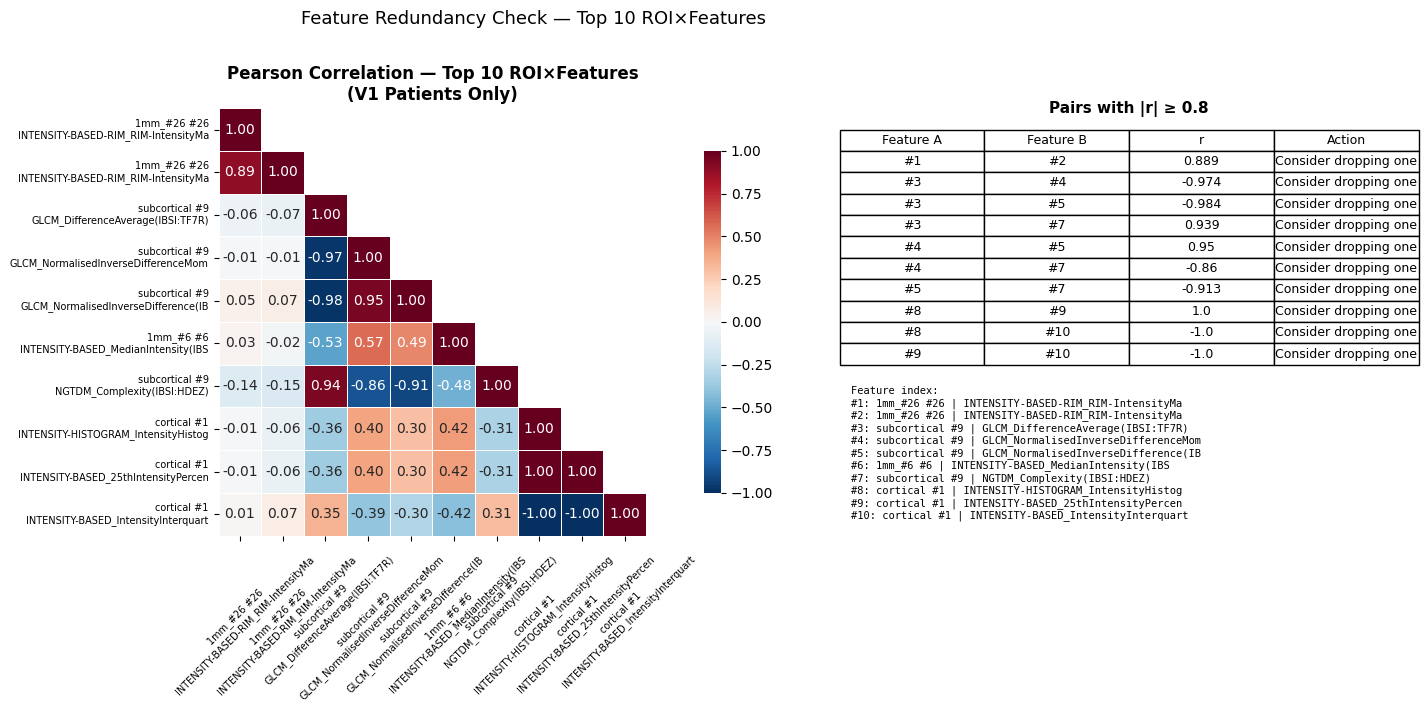


Correlation range across all pairs:
  min=-1.000  max=1.000  mean=-0.041


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load top 10 features ──────────────────────────────────────────────────────
top10 = pd.read_csv('/Users/gracieshao/Desktop/ALS T1s/Scripts/top10_ttest_roi_features_combined.csv')
top10_cols = (top10['roi'] + '__' + top10['feature']).tolist()

print(f"Top 10 features loaded: {len(top10_cols)}")

# ── Pivot v1_df patients to wide format (one row per patient) ─────────────────
# v1_df, patient_mask should be in memory from Levene cell
FEAT_COLS_ALL = [c for c in v1_df.columns
                 if c not in ['INFO_PatientName', 'INFO_NameOfRoi',
                               'Study', 'SiteCode', 'SubjectID', 'Visit', 'Group']]

wide_pat = v1_df[patient_mask].pivot_table(
    index   = 'INFO_PatientName',
    columns = 'INFO_NameOfRoi',
    values  = FEAT_COLS_ALL,
    aggfunc = 'first'
)
wide_pat.columns = [f"{roi}__{feat}" for feat, roi in wide_pat.columns]
wide_pat = wide_pat.reset_index()

# ── Check all top10 cols exist ────────────────────────────────────────────────
missing = [c for c in top10_cols if c not in wide_pat.columns]
if missing:
    print(f"WARNING — missing columns: {missing}")
top10_cols = [c for c in top10_cols if c in wide_pat.columns]

X = wide_pat[top10_cols].copy()
print(f"Patient matrix for correlation: {X.shape}")

# ── Pearson correlation matrix ────────────────────────────────────────────────
corr = X.corr(method='pearson')

# ── Short labels: ROI#XX + truncated feature name ────────────────────────────
def short_label(roi, feat, max_feat=35):
    roi_num = next((p for p in roi.split('_') if p.startswith('#')), roi[-4:])
    roi_short = roi.split('_label_all')[0].split('-')[-1] + ' ' + roi_num
    return f"{roi_short}\n{feat[:max_feat]}"

labels = [short_label(row['roi'], row['feature'])
          for _, row in top10.iterrows()
          if f"{row['roi']}__{row['feature']}" in top10_cols]

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                          gridspec_kw={'width_ratios': [2, 1]})

# Panel 1 — full correlation heatmap
ax = axes[0]
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)   # hide upper triangle
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            mask=mask_upper,
            ax=ax,
            xticklabels=labels,
            yticklabels=labels,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation — Top 10 ROI×Features\n(V1 Patients Only)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7, rotation=0)

# Panel 2 — flag highly correlated pairs
THRESHOLD = 0.8
ax2 = axes[1]
ax2.axis('off')

flagged = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) >= THRESHOLD:
            flagged.append({
                'Feature A': f"#{i+1}",
                'Feature B': f"#{j+1}",
                'r':         round(r, 3),
                'Action':    'Consider dropping one'
            })

if flagged:
    flag_df = pd.DataFrame(flagged)
    tbl = ax2.table(
        cellText  = flag_df.values,
        colLabels = flag_df.columns,
        cellLoc   = 'center', loc='center',
        bbox      = [0, 0.4, 1, 0.55]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    ax2.set_title(f'Pairs with |r| ≥ {THRESHOLD}', fontsize=11, fontweight='bold', y=0.97)
    print(f"\nHighly correlated pairs (|r| ≥ {THRESHOLD}):")
    print(flag_df.to_string(index=False))
else:
    ax2.text(0.5, 0.5, f'No pairs with |r| ≥ {THRESHOLD}',
             ha='center', va='center', fontsize=11,
             transform=ax2.transAxes)
    ax2.set_title(f'Pairs with |r| ≥ {THRESHOLD}', fontsize=11, fontweight='bold')
    print(f"\nNo highly correlated pairs found (|r| ≥ {THRESHOLD}).")

# Feature index legend
legend_txt = '\n'.join([f"#{i+1}: {lab.replace(chr(10), ' | ')}"
                         for i, lab in enumerate(labels)])
ax2.text(0.02, 0.35, 'Feature index:\n' + legend_txt,
         transform=ax2.transAxes, fontsize=7.5,
         verticalalignment='top', fontfamily='monospace')

plt.suptitle('Feature Redundancy Check — Top 10 ROI×Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(
    '/Users/gracieshao/Desktop/ALS T1s/data/preprocessed/top10_correlation_heatmap.png',
    dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nCorrelation range across all pairs:")
corr_vals = corr.values[np.tril_indices_from(corr.values, k=-1)]
print(f"  min={corr_vals.min():.3f}  max={corr_vals.max():.3f}  "
      f"mean={corr_vals.mean():.3f}")

# Select top 10 features that are not highly correlated

T-test significant features: 80
Valid columns found: 80

Greedy selection (threshold |r| ≥ 0.8):

  ✓ # 1  p_fdr=4.9006e-11  JHU-WhiteMatter-labels-1mm_#26__INTENSITY-BASED-RIM_RIM-IntensityMax-G
  ✗ skip  p_fdr=1.1922e-09  JHU-WhiteMatter-labels-1mm_#26__INTENSITY-BASED-RIM_RIM  |r|=0.889 with JHU-WhiteMatter-labels-1mm_#26__INTENSIT
  ✓ # 2  p_fdr=1.1922e-09  harvardoxford-subcortical_label_all_#9__GLCM_DifferenceAverage(IBSI:TF
  ✗ skip  p_fdr=1.2765e-09  harvardoxford-subcortical_label_all_#9__GLCM_Normalised  |r|=0.974 with harvardoxford-subcortical_label_all_#9__
  ✗ skip  p_fdr=1.2765e-09  harvardoxford-subcortical_label_all_#9__GLCM_Normalised  |r|=0.984 with harvardoxford-subcortical_label_all_#9__
  ✓ # 3  p_fdr=1.5279e-09  JHU-WhiteMatter-labels-1mm_#6__INTENSITY-BASED_MedianIntensity(IBSI:Y1
  ✗ skip  p_fdr=8.7135e-08  harvardoxford-subcortical_label_all_#9__NGTDM_Complexit  |r|=0.939 with harvardoxford-subcortical_label_all_#9__
  ✓ # 4  p_fdr=6.7693e-07  harvardoxford-cor

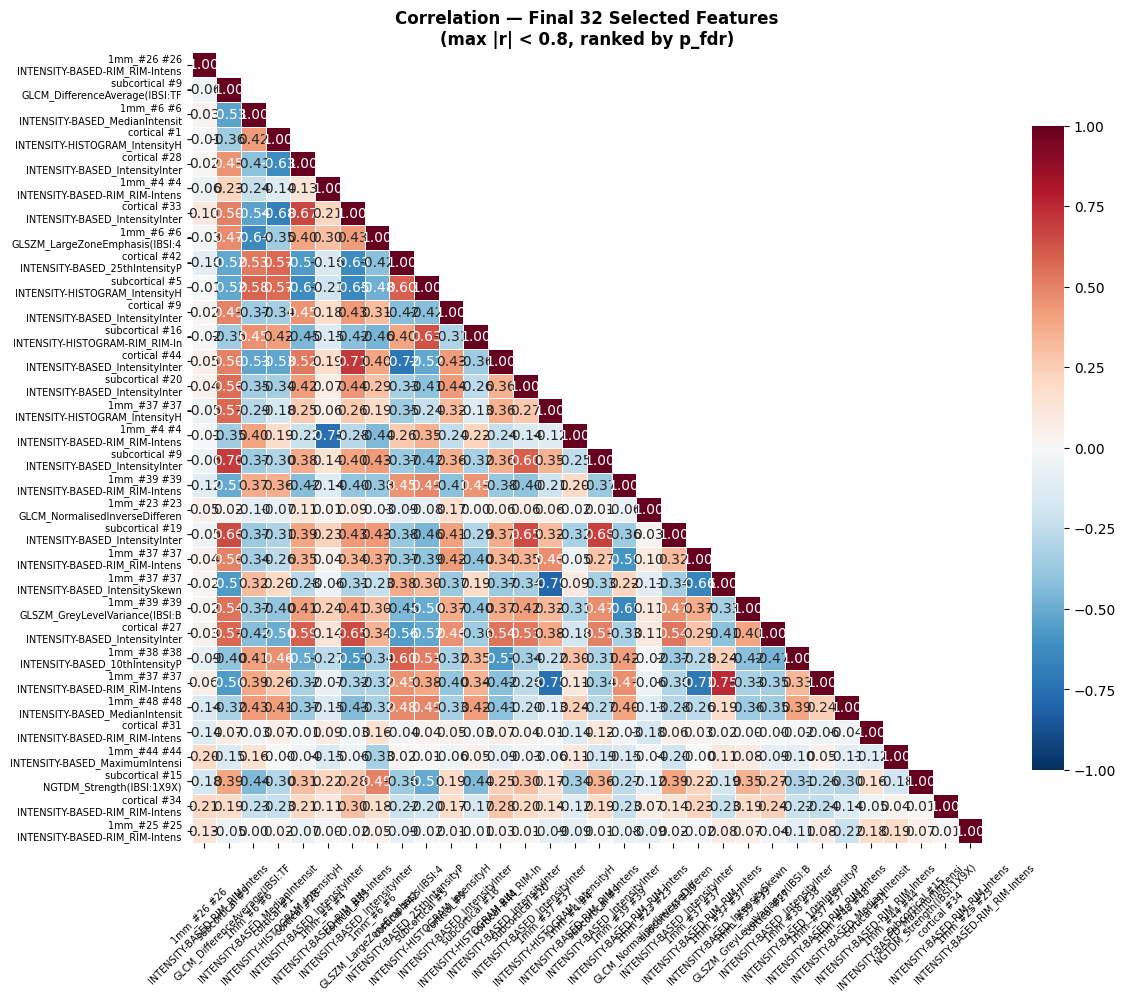

Saved: top10_ttest_uncorrelated_roi_features_combined.csv


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

THRESHOLD = 0.8
N_SELECT  = 10

# ── Load t-test results, ranked by p_fdr ─────────────────────────────────────
ttest_df = pd.read_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/ttest_sig_roi_features_combined.csv')
ttest_df = ttest_df.sort_values('p_fdr', ascending=True).reset_index(drop=True)
ttest_df['col'] = ttest_df['roi'] + '__' + ttest_df['feature']
print(f"T-test significant features: {len(ttest_df)}")

# ── Build wide patient matrix ─────────────────────────────────────────────────
FEAT_COLS_ALL = [c for c in v1_df.columns
                 if c not in ['INFO_PatientName', 'INFO_NameOfRoi',
                               'Study', 'SiteCode', 'SubjectID', 'Visit', 'Group']]

wide_pat = v1_df[patient_mask].pivot_table(
    index   = 'INFO_PatientName',
    columns = 'INFO_NameOfRoi',
    values  = FEAT_COLS_ALL,
    aggfunc = 'first'
)
wide_pat.columns = [f"{roi}__{feat}" for feat, roi in wide_pat.columns]
wide_pat = wide_pat.reset_index()

# ── Filter to valid columns ───────────────────────────────────────────────────
ttest_df = ttest_df[ttest_df['col'].isin(wide_pat.columns)].reset_index(drop=True)
print(f"Valid columns found: {len(ttest_df)}")

# ── Greedy selection: best p_fdr first, skip if correlated with any selected ──
selected_cols = []
selected_rows = []

print(f"\nGreedy selection (threshold |r| ≥ {THRESHOLD}):\n")

for _, row in ttest_df.iterrows():
    col = row['col']

    if not selected_cols:
        # First feature always added
        selected_cols.append(col)
        selected_rows.append(row)
        print(f"  ✓ #{len(selected_cols):2d}  p_fdr={row['p_fdr']:.4e}  {col[:70]}")
        continue

    # Check correlation against all already-selected features
    cand = wide_pat[col].values
    correlated_with = None

    for sel_col in selected_cols:
        sel = wide_pat[sel_col].values
        valid = ~(np.isnan(cand) | np.isnan(sel))
        if valid.sum() < 10:
            continue
        r = np.corrcoef(cand[valid], sel[valid])[0, 1]
        if abs(r) >= THRESHOLD:
            correlated_with = (sel_col, r)
            break

    if correlated_with:
        print(f"  ✗ skip  p_fdr={row['p_fdr']:.4e}  {col[:55]}"
              f"  |r|={abs(correlated_with[1]):.3f} with {correlated_with[0][:40]}")
    else:
        selected_cols.append(col)
        selected_rows.append(row)
        print(f"  ✓ #{len(selected_cols):2d}  p_fdr={row['p_fdr']:.4e}  {col[:70]}")

    # if len(selected_cols) == N_SELECT:
    #     break

if len(selected_cols) < N_SELECT:
    print(f"\nWARNING: Only found {len(selected_cols)} uncorrelated features "
          f"(threshold may be too strict — consider lowering to 0.7 or 0.9)")

# # ── Final top-N dataframe ─────────────────────────────────────────────────────
# top10_final = pd.DataFrame(selected_rows).drop(columns=['col']).reset_index(drop=True)

# print(f"\n=== Final {len(selected_cols)} features ===")
# print(top10_final[['roi','feature','p_fdr','cohens_d',
#                     'pat_mean','ctrl_mean','n_pat','n_ctrl']].to_string(index=False))

# ── Final dataframe — all features kept after greedy selection ────────────────
selected_final = pd.DataFrame(selected_rows).drop(columns=['col']).reset_index(drop=True)

print(f"\n=== Features kept after greedy selection: {len(selected_final)} ===")
print(selected_final[['roi','feature','p_fdr','cohens_d',
                       'pat_mean','ctrl_mean','n_pat','n_ctrl']].to_string(index=False))

# ── Save ──────────────────────────────────────────────────────────────────────
selected_final.to_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/greedy_selected_roi_features_combined.csv',
    index=False)
print(f"\nSaved: greedy_selected_roi_features_combined.csv  ({len(selected_final)} features)")
for i, row in selected_final.iterrows():
    print(f"  {i+1:2d}. [{row['roi']}]  {row['feature']}")
    print(f"       p_fdr={row['p_fdr']:.4e}  Cohen's d={row['cohens_d']:.3f}")
    

# ── Verify: correlation heatmap of selected features ─────────────────────────
X_final = wide_pat[selected_cols].copy()
corr    = X_final.corr(method='pearson')

def short_label(col):
    parts = col.split('__')
    roi_num = next((p for p in parts[0].split('_') if p.startswith('#')), parts[0][-4:])
    roi_short = parts[0].split('_label')[0].split('-')[-1] + ' ' + roi_num
    return f"{roi_short}\n{parts[1][:30]}"

labels = [short_label(c) for c in selected_cols]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            mask=np.triu(np.ones_like(corr, dtype=bool), k=1),
            ax=ax,
            xticklabels=labels, yticklabels=labels,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title(f'Correlation — Final {len(selected_cols)} Selected Features\n'
             f'(max |r| < {THRESHOLD}, ranked by p_fdr)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7, rotation=0)
plt.tight_layout()
plt.savefig(
    '/Users/gracieshao/Desktop/ALS T1s/data/preprocessed/'
    'top10_uncorrelated_correlation_heatmap.png',
    dpi=150, bbox_inches='tight')
plt.show()

# ── Save ─────────────────────────────────────────────────────────────────────
top10_final.to_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/top10_ttest_uncorrelated_roi_features_combined.csv',
    index=False)
print(f"Saved: top10_ttest_uncorrelated_roi_features_combined.csv")

T-test significant features: 80
Valid columns found: 80

Greedy selection (threshold |r| ≥ 0.8):

  ✓ # 1  p_fdr=4.9006e-11  JHU-WhiteMatter-labels-1mm_#26__INTENSITY-BASED-RIM_RIM-IntensityMax-G
  ✗ skip  p_fdr=1.1922e-09  JHU-WhiteMatter-labels-1mm_#26__INTENSITY-BASED-RIM_RIM  |r|=0.889 with JHU-WhiteMatter-labels-1mm_#26__INTENSIT
  ✓ # 2  p_fdr=1.1922e-09  harvardoxford-subcortical_label_all_#9__GLCM_DifferenceAverage(IBSI:TF
  ✗ skip  p_fdr=1.2765e-09  harvardoxford-subcortical_label_all_#9__GLCM_Normalised  |r|=0.974 with harvardoxford-subcortical_label_all_#9__
  ✗ skip  p_fdr=1.2765e-09  harvardoxford-subcortical_label_all_#9__GLCM_Normalised  |r|=0.984 with harvardoxford-subcortical_label_all_#9__
  ✓ # 3  p_fdr=1.5279e-09  JHU-WhiteMatter-labels-1mm_#6__INTENSITY-BASED_MedianIntensity(IBSI:Y1
  ✗ skip  p_fdr=8.7135e-08  harvardoxford-subcortical_label_all_#9__NGTDM_Complexit  |r|=0.939 with harvardoxford-subcortical_label_all_#9__
  ✓ # 4  p_fdr=6.7693e-07  harvardoxford-cor

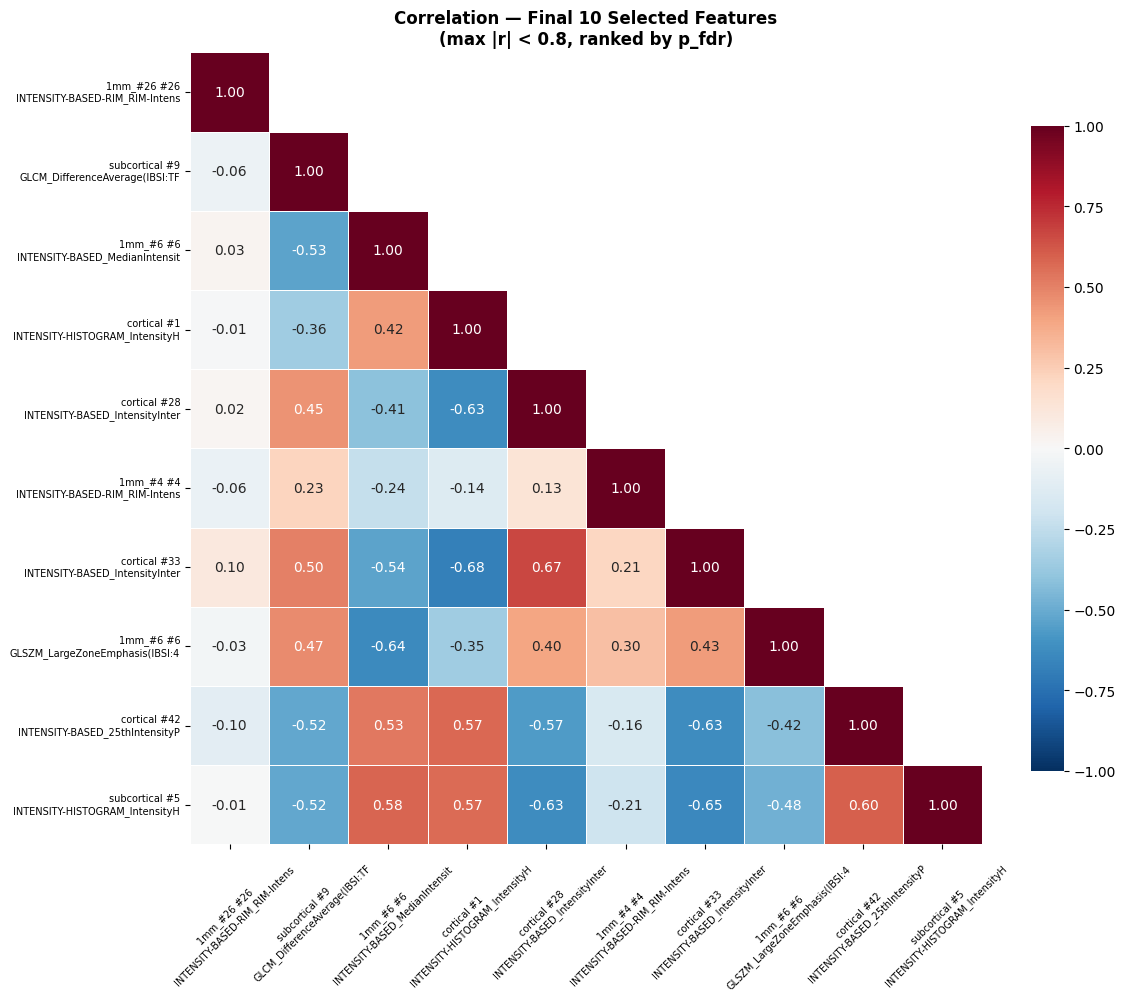

Saved: top10_ttest_uncorrelated_roi_features_combined.csv


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

THRESHOLD = 0.8
N_SELECT  = 10

# ── Load t-test results, ranked by p_fdr ─────────────────────────────────────
ttest_df = pd.read_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/ttest_sig_roi_features_combined.csv')
ttest_df = ttest_df.sort_values('p_fdr', ascending=True).reset_index(drop=True)
ttest_df['col'] = ttest_df['roi'] + '__' + ttest_df['feature']
print(f"T-test significant features: {len(ttest_df)}")

# ── Build wide patient matrix ─────────────────────────────────────────────────
FEAT_COLS_ALL = [c for c in v1_df.columns
                 if c not in ['INFO_PatientName', 'INFO_NameOfRoi',
                               'Study', 'SiteCode', 'SubjectID', 'Visit', 'Group']]

wide_pat = v1_df[patient_mask].pivot_table(
    index   = 'INFO_PatientName',
    columns = 'INFO_NameOfRoi',
    values  = FEAT_COLS_ALL,
    aggfunc = 'first'
)
wide_pat.columns = [f"{roi}__{feat}" for feat, roi in wide_pat.columns]
wide_pat = wide_pat.reset_index()

# ── Filter to valid columns ───────────────────────────────────────────────────
ttest_df = ttest_df[ttest_df['col'].isin(wide_pat.columns)].reset_index(drop=True)
print(f"Valid columns found: {len(ttest_df)}")

# ── Greedy selection: best p_fdr first, skip if correlated with any selected ──
selected_cols = []
selected_rows = []

print(f"\nGreedy selection (threshold |r| ≥ {THRESHOLD}):\n")

for _, row in ttest_df.iterrows():
    col = row['col']

    if not selected_cols:
        # First feature always added
        selected_cols.append(col)
        selected_rows.append(row)
        print(f"  ✓ #{len(selected_cols):2d}  p_fdr={row['p_fdr']:.4e}  {col[:70]}")
        continue

    # Check correlation against all already-selected features
    cand = wide_pat[col].values
    correlated_with = None

    for sel_col in selected_cols:
        sel = wide_pat[sel_col].values
        valid = ~(np.isnan(cand) | np.isnan(sel))
        if valid.sum() < 10:
            continue
        r = np.corrcoef(cand[valid], sel[valid])[0, 1]
        if abs(r) >= THRESHOLD:
            correlated_with = (sel_col, r)
            break

    if correlated_with:
        print(f"  ✗ skip  p_fdr={row['p_fdr']:.4e}  {col[:55]}"
              f"  |r|={abs(correlated_with[1]):.3f} with {correlated_with[0][:40]}")
    else:
        selected_cols.append(col)
        selected_rows.append(row)
        print(f"  ✓ #{len(selected_cols):2d}  p_fdr={row['p_fdr']:.4e}  {col[:70]}")

    if len(selected_cols) == N_SELECT:
        break

if len(selected_cols) < N_SELECT:
    print(f"\nWARNING: Only found {len(selected_cols)} uncorrelated features "
          f"(threshold may be too strict — consider lowering to 0.7 or 0.9)")

# ── Final top-N dataframe ─────────────────────────────────────────────────────
top10_final = pd.DataFrame(selected_rows).drop(columns=['col']).reset_index(drop=True)

print(f"\n=== Final {len(selected_cols)} features ===")
print(top10_final[['roi','feature','p_fdr','cohens_d',
                    'pat_mean','ctrl_mean','n_pat','n_ctrl']].to_string(index=False))


# ── Verify: correlation heatmap of selected features ─────────────────────────
X_final = wide_pat[selected_cols].copy()
corr    = X_final.corr(method='pearson')

def short_label(col):
    parts = col.split('__')
    roi_num = next((p for p in parts[0].split('_') if p.startswith('#')), parts[0][-4:])
    roi_short = parts[0].split('_label')[0].split('-')[-1] + ' ' + roi_num
    return f"{roi_short}\n{parts[1][:30]}"

labels = [short_label(c) for c in selected_cols]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            mask=np.triu(np.ones_like(corr, dtype=bool), k=1),
            ax=ax,
            xticklabels=labels, yticklabels=labels,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title(f'Correlation — Final {len(selected_cols)} Selected Features\n'
             f'(max |r| < {THRESHOLD}, ranked by p_fdr)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7, rotation=0)
plt.tight_layout()
plt.savefig(
    '/Users/gracieshao/Desktop/ALS T1s/data/preprocessed/'
    'top10_uncorrelated_correlation_heatmap.png',
    dpi=150, bbox_inches='tight')
plt.show()

# ── Save ─────────────────────────────────────────────────────────────────────
top10_final.to_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/top10_ttest_uncorrelated_roi_features_combined.csv',
    index=False)
print(f"Saved: top10_ttest_uncorrelated_roi_features_combined.csv")

In [12]:
pd.DataFrame(selected_rows)

,roi,feature,var_ratio,t_stat,p_ttest,cohens_d,abs_d,pat_mean,ctrl_mean,pat_std,ctrl_std,n_pat,n_ctrl,p_fdr,col
0,harvardoxford-subcortical_label_all_#9,GLCM_DifferenceAverage(IBSI:TF7R),1.834365,6.829626,2.768230e-11,0.633182,0.633182,0.298167,-0.012567,0.558328,0.412236,252,204,1.521974e-09,harvardoxford-subcortical_label_all_#9__GLCM_D...
3,JHU-WhiteMatter-labels-1mm_#6,INTENSITY-BASED_MedianIntensity(IBSI:Y12H)[],1.395261,-6.673776,7.298653e-11,-0.623065,0.623065,-2.653821,-1.487602,2.020287,1.710351,252,204,1.696937e-09,JHU-WhiteMatter-labels-1mm_#6__INTENSITY-BASED...
5,harvardoxford-cortical_label_all_#1,INTENSITY-HISTOGRAM_IntensityHistogram25thPerc...,1.209669,-5.435508,8.993542e-08,-0.509363,0.509363,-0.725574,-0.253203,0.970377,0.882282,252,204,1.208684e-06,harvardoxford-cortical_label_all_#1__INTENSITY...
8,harvardoxford-cortical_label_all_#28,INTENSITY-BASED_IntensityInterquartileRange(IB...,1.888704,5.327328,1.579600e-07,0.493546,0.493546,0.812213,0.228519,1.352392,0.984058,252,204,1.632253e-06,harvardoxford-cortical_label_all_#28__INTENSIT...
9,harvardoxford-subcortical_label_all_#5,INTENSITY-BASED_10thIntensityPercentile(IBSI:Q...,1.468488,-5.057792,6.168050e-07,-0.471570,0.471570,0.064696,0.418838,0.819155,0.675975,252,204,4.513450e-06,harvardoxford-subcortical_label_all_#5__INTENS...
11,JHU-WhiteMatter-labels-1mm_#6,GLSZM_ZoneSizeVariance(IBSI:3NSA),2.283495,5.048142,6.556751e-07,0.465553,0.465553,-0.096963,-0.099758,0.007081,0.004685,252,204,4.513450e-06,JHU-WhiteMatter-labels-1mm_#6__GLSZM_ZoneSizeV...
13,JHU-WhiteMatter-labels-1mm_#4,INTENSITY-BASED-RIM_RIM-IntensityMean_Std(IBSI...,13.061715,5.119625,5.521295e-07,0.460729,0.460729,-0.391295,-0.621777,0.681848,0.188663,251,204,4.513450e-06,JHU-WhiteMatter-labels-1mm_#4__INTENSITY-BASED...
14,harvardoxford-cortical_label_all_#33,INTENSITY-BASED_IntensityInterquartileRange(IB...,1.445869,5.014391,7.645392e-07,0.467711,0.467711,1.150845,0.549858,1.397172,1.161944,252,204,4.740143e-06,harvardoxford-cortical_label_all_#33__INTENSIT...
15,harvardoxford-cortical_label_all_#42,INTENSITY-BASED_IntensityInterquartileRange(IB...,1.361289,4.954242,1.027607e-06,0.462827,0.462827,1.217892,0.601798,1.429368,1.225093,252,204,5.972967e-06,harvardoxford-cortical_label_all_#42__INTENSIT...
22,harvardoxford-cortical_label_all_#9,INTENSITY-BASED_IntensityInterquartileRange(IB...,2.759361,4.693698,3.633453e-06,0.431035,0.431035,0.360526,-0.049320,1.152047,0.693531,252,204,1.469179e-05,harvardoxford-cortical_label_all_#9__INTENSITY...
